# COE Price Forecasting — exploration & model tuning

We forecast Singapore COE premiums for **all five categories** — A (cars ≤1600cc / ≤130bhp),
B (larger cars), C (goods vehicles & buses), D (motorcycles), E (open) — using SARIMAX,
one model per category, and report an **honest, backtested MAPE** (forecast the most recent real bidding rounds as if unknown, compare vs. actual).

| Step | What it does |
|---|---|
| 1 | Setup: libraries, parameters, fetch the data from data.gov.sg, cache a local snapshot |
| 2 | Clean & reshape into one monthly time series per category |
| 3 | Explore: plot the series, check what the data looks like |
| 4 | SARIMAX per category |
| 5 | Honest backtest: hold out recent rounds, forecast them, measure MAPE |
| 6 | Save the fitted model + forecast for the Streamlit app |

**Data source (verified live):** `d_69b3380ad7e51aff3a7dcc84eba52b8a` — COE bidding results,
monthly since 2010, one row per category per bidding round. It already contains the target
(`premium`) **and** both planned exogenous features (`quota`, `bids_received`), so no second
dataset is needed for v1.

## Step 1 — Setup

### 1.1 — Libraries

In [1]:
import requests
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

# pandas 2.3.0 emits false-positive ChainedAssignmentError FutureWarnings on plain
# column assignment (fixed in 2.3.1) — silence just that message
warnings.filterwarnings("ignore", message=".*ChainedAssignmentError.*")

### 1.2 — Parameters

In [2]:
# data.gov.sg dataset: COE bidding results, monthly since 2010
DATASET_ID = "d_69b3380ad7e51aff3a7dcc84eba52b8a"
API_URL = "https://data.gov.sg/api/action/datastore_search"

# Local snapshot — the Streamlit app falls back to this if the live API is down
ROOT = Path.cwd()
RAW_CSV = ROOT / "dataset" / "coe_bidding_raw.csv"

# All five COE categories, one model each
CATEGORIES = ["Category A", "Category B", "Category C", "Category D", "Category E"]

### 1.3 — Fetch the data

The API returns at most a few hundred rows per call, so we page through it with `offset`
until we have everything. The dataset is small (~2,000 rows), so this takes a few seconds.

In [3]:
def fetch_all(dataset_id):
    """
    Every record in the dataset, as a DataFrame. Pages through the API 1000 rows at a time.
    """
    records = []
    offset = 0

    while True:
        response = requests.get(API_URL,
                                params={"resource_id": dataset_id,
                                        "limit": 1000,
                                        "offset": offset},
                                timeout=30)
        result = response.json()["result"]
        records.extend(result["records"])

        # Stop once we have every row the API says exists
        if len(records) >= result["total"]:
            break
        offset += 1000

    return pd.DataFrame(records)

raw = fetch_all(DATASET_ID)
print(f"{len(raw):,} rows x {len(raw.columns)} columns")
raw.head(3)

1,975 rows x 8 columns


,_id,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,1,2010-01,1,Category A,1152,1145,1342,18502
1,2,2010-01,1,Category B,687,679,883,19190
2,3,2010-01,1,Category C,173,173,265,19001


### 1.4 — First look

What we expect: one row per category per bidding round, two rounds per month
(1st and 2nd bidding exercise), 5 categories, from 2010-01 to the latest round.

In [4]:
print("date range: ", raw["month"].min(), "to", raw["month"].max())
print("bidding_no: ", sorted(raw["bidding_no"].unique()))
print()
print(raw["vehicle_class"].value_counts())

date range:  2010-01 to 2026-09
bidding_no:  ['1', '2']

vehicle_class
Category A    395
Category B    395
Category C    395
Category D    395
Category E    395
Name: count, dtype: int64


### 1.5 — Cache a local snapshot

The raw data is saved to `dataset/coe_bidding_raw.csv`. This is the demo-reliability fallback:
the Streamlit app reads this file if the live API is slow or down while someone is viewing it.

In [5]:
RAW_CSV.parent.mkdir(parents=True, exist_ok=True)
raw.to_csv(RAW_CSV, index=False)
print(f"saved {RAW_CSV.relative_to(ROOT)}  ({len(raw):,} rows)")

saved dataset/coe_bidding_raw.csv  (1,975 rows)


## Step 2 — Clean & reshape

Goal: one tidy time series per category, one row per **bidding round**, sorted oldest → newest,
with numeric columns. The model forecasts the next bidding round — the question people actually
ask ("what will the next COE round close at?").

### 2.1 — Numeric conversion

The API returns every value as text, and rounds from mid-2023 onwards use thousands
separators (`"1,184"`) while older rounds don't (`"18502"`) — so we strip commas
before converting. Without this, `pd.to_numeric` silently NaNs out 109 recent
`bids_received` values — exactly the rounds the backtest needs.

In [6]:
coe = raw.copy()

for column in ["quota", "bids_success", "bids_received", "premium"]:
    # Strip thousands separators ("1,184" -> "1184") before converting
    coe[column] = pd.to_numeric(coe[column].astype(str).str.replace(",", ""), errors="coerce")

# Check nothing failed to convert
print(coe[["quota", "bids_success", "bids_received", "premium"]].isna().sum())
coe.dtypes

quota            0
bids_success     0
bids_received    0
premium          0
dtype: int64


_id               int64
month            object
bidding_no       object
vehicle_class    object
quota             int64
bids_success      int64
bids_received     int64
premium           int64
dtype: object

### 2.2 — A sortable date per bidding round

Each round is identified by `month` + `bidding_no`. We give each round a real date so the series
sorts correctly and plots have a proper time axis: 1st exercise → day 1, 2nd exercise → day 15
(the actual exercises are held in the 1st and 3rd week of the month).

In [7]:
def round_date(month, bidding_no):
    """
    '2010-01' + '2' -> Timestamp 2010-01-15. First exercise -> day 1, second -> day 15.
    """
    if str(bidding_no) == "1":
        day = 1
    else:
        day = 15
    return pd.Timestamp(f"{month}-{day:02d}")

# Example:
print(round_date("2010-01", "1"), "|", round_date("2010-01", "2"), "|", round_date("2026-09", "1"))

2010-01-01 00:00:00 | 2010-01-15 00:00:00 | 2026-09-01 00:00:00


In [8]:
coe["round_date"] = [round_date(m, b) for m, b in zip(coe["month"], coe["bidding_no"])]
coe = coe.sort_values("round_date")
coe[["round_date", "vehicle_class", "quota", "bids_received", "premium"]].head(4)

,round_date,vehicle_class,quota,bids_received,premium
0,2010-01-01,Category A,1152,1342,18502
1,2010-01-01,Category B,687,883,19190
2,2010-01-01,Category C,173,265,19001
3,2010-01-01,Category D,373,509,889


### 2.3 — Are any bidding rounds missing?

201 months × 2 rounds = 402 possible rounds, but we counted 395 per category in Step 1.4.
Before modelling, we find out exactly which rounds are missing and why.

In [9]:
# Every round that should exist vs. every round that does (using Category A as the reference)
cat_a_rounds = set(coe.loc[coe["vehicle_class"] == "Category A", "round_date"])

all_months = pd.period_range("2010-01", "2026-09", freq="M")
expected = []
for month in all_months:
    for bid_no in ["1", "2"]:
        expected.append(round_date(str(month), bid_no))

missing = sorted(set(expected) - cat_a_rounds)
print(f"{len(cat_a_rounds)} rounds present, {len(missing)} missing:")
for date in missing:
    print("   x", date.date())

395 rounds present, 7 missing:
   x 2020-04-01
   x 2020-04-15
   x 2020-05-01
   x 2020-05-15
   x 2020-06-01
   x 2020-06-15
   x 2026-09-15


### 2.4 — One series per category

A dict of DataFrames — `series["Category A"]` and `series["Category B"]` — each indexed by
`round_date` with the target (`premium`) and the two exogenous features (`quota`, `bids_received`).

In [10]:
series = {}
for category in CATEGORIES:
    rows = coe[coe["vehicle_class"] == category]
    series[category] = (rows.set_index("round_date")
                            [["premium", "quota", "bids_received"]])

for category, s in series.items():
    print(f"{category}: {len(s)} rounds, {s.index.min().date()} to {s.index.max().date()}, "
          f"latest premium ${s['premium'].iloc[-1]:,.0f}")

series["Category A"].tail(3)

Category A: 395 rounds, 2010-01-01 to 2026-09-01, latest premium $133,009
Category B: 395 rounds, 2010-01-01 to 2026-09-01, latest premium $135,001
Category C: 395 rounds, 2010-01-01 to 2026-09-01, latest premium $93,101
Category D: 395 rounds, 2010-01-01 to 2026-09-01, latest premium $12,556
Category E: 395 rounds, 2010-01-01 to 2026-09-01, latest premium $137,890


,premium,quota,bids_received
round_date,,,
2026-08-01,123890,1226,1522
2026-08-15,128501,1197,1600
2026-09-01,133009,1195,1708


## Step 3 — Explore the series

Before modelling, we look at what we're forecasting. Two questions:

1. **What does the premium series look like?** Trend, level shifts, the COVID gap —
   this tells us whether differencing is needed (it will be: COE prices trend hard).
2. **Does demand pressure (bids ÷ quota) track the premium?** If yes, our two
   exogenous features earn their place in the model.

### 3.1 — Chart style

One place for the shared plot style: category colors are fixed (Cat A is always blue,
Cat B always orange, on every chart), grid and axes stay recessive.

In [11]:
COLOR = {"Category A": "#2a78d6", "Category B": "#eb6834",
         "Category C": "#1baf7a", "Category D": "#eda100", "Category E": "#e87ba4"}

# COVID bidding suspension — shaded on every time plot
COVID_START = pd.Timestamp("2020-04-01")
COVID_END = pd.Timestamp("2020-06-30")

def style_axis(ax):
    """
    Recessive grid and axes: light dotted grid, no top/right spines.
    """
    ax.grid(True, alpha=0.25, linestyle=":")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

### 3.2 — Premium over time

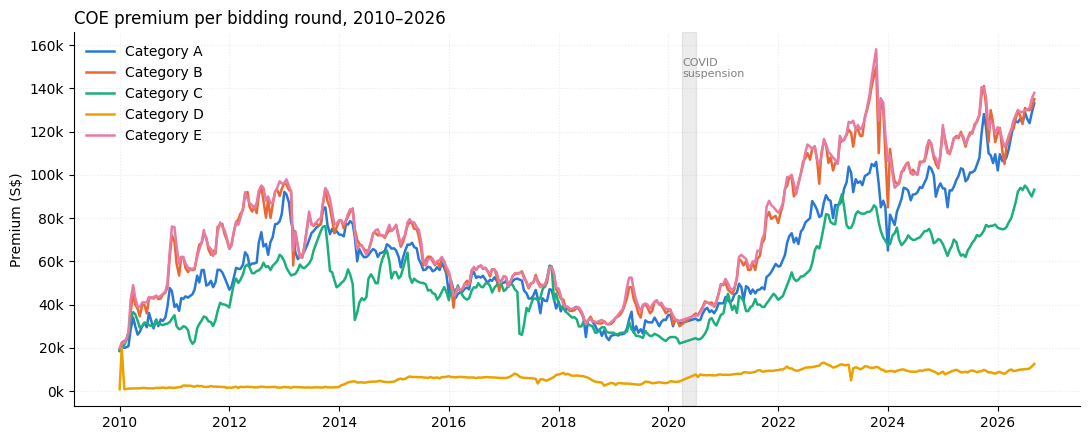

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))

for category in CATEGORIES:
    s = series[category]
    ax.plot(s.index, s["premium"], color=COLOR[category], linewidth=1.8, label=category)

ax.axvspan(COVID_START, COVID_END, color="gray", alpha=0.15)
ax.annotate("COVID\nsuspension", xy=(COVID_START, 145000), fontsize=8, color="gray")

ax.set_title("COE premium per bidding round, 2010–2026", loc="left")
ax.set_ylabel("Premium (S$)")
ax.yaxis.set_major_formatter(lambda value, pos: f"{value/1000:.0f}k")
ax.legend(frameon=False, loc="upper left")
style_axis(ax)
plt.tight_layout()
plt.show()

**What the plot shows, and what it means for the model:**

- **Strong trends, no fixed level** — the series wanders from ~$20k to ~$135k.
  SARIMAX will need differencing (`d=1`): we model round-to-round *changes*, not levels.
- **No obvious annual seasonality** — COE prices are driven by quota policy and demand
  cycles, not the calendar. We start without a seasonal term and let the backtest judge.
- **Regimes**: the 2010–2013 climb (quota crunch), the 2015–2019 plateau, the post-COVID
  surge to the 2023 peak, and the current 2025–2026 climb. Recent history matters far
  more than 2010 history — another argument for differencing.

### 3.3 — Does demand pressure track the premium?

The intuition behind our exogenous features: when many bids chase few certificates,
the price is bid up. We plot the ratio **bids received ÷ quota** next to the premium
(indexed to a common scale is overkill here — two stacked panels, one measure each).

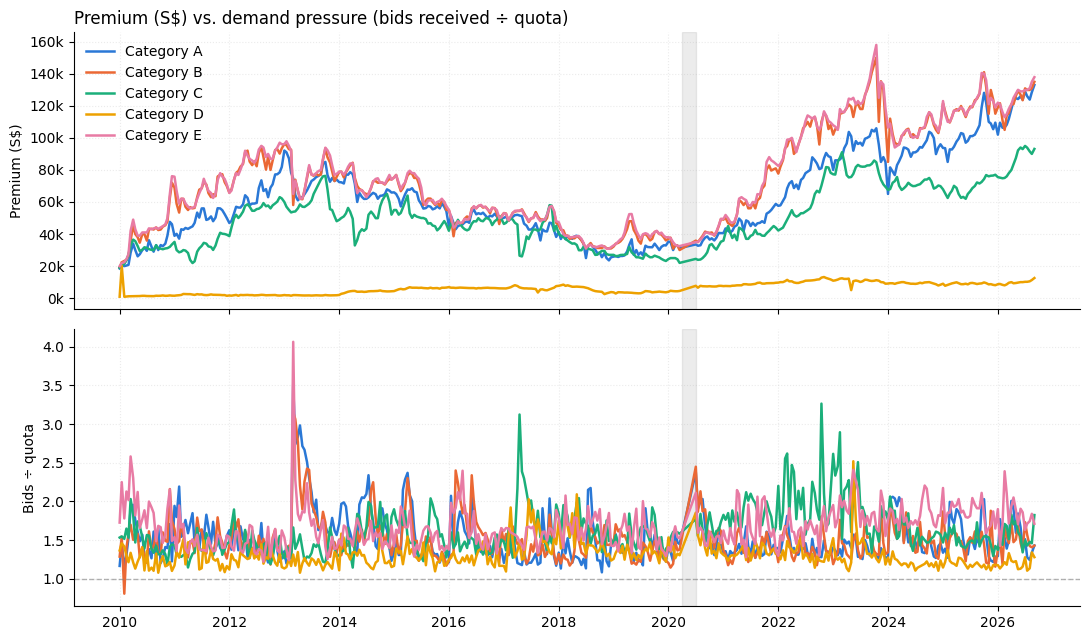

Category A:
  pressure level vs premium level   =  0.09
  pressure level vs premium change  =  0.25
  PREVIOUS pressure vs premium change = -0.00
Category B:
  pressure level vs premium level   =  0.02
  pressure level vs premium change  =  0.30
  PREVIOUS pressure vs premium change =  0.07
Category C:
  pressure level vs premium level   =  0.11
  pressure level vs premium change  =  0.09
  PREVIOUS pressure vs premium change =  0.14
Category D:
  pressure level vs premium level   =  0.08
  pressure level vs premium change  =  0.10
  PREVIOUS pressure vs premium change = -0.01
Category E:
  pressure level vs premium level   =  0.21
  pressure level vs premium change  =  0.06
  PREVIOUS pressure vs premium change =  0.17


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

for category in CATEGORIES:
    s = series[category]
    axes[0].plot(s.index, s["premium"], color=COLOR[category], linewidth=1.8, label=category)
    axes[1].plot(s.index, s["bids_received"] / s["quota"], color=COLOR[category], linewidth=1.8)

axes[0].set_title("Premium (S$) vs. demand pressure (bids received ÷ quota)", loc="left")
axes[0].set_ylabel("Premium (S$)")
axes[0].yaxis.set_major_formatter(lambda value, pos: f"{value/1000:.0f}k")
axes[0].legend(frameon=False, loc="upper left")

axes[1].axhline(1.0, color="gray", linewidth=1, linestyle="--", alpha=0.6)
axes[1].set_ylabel("Bids ÷ quota")

for ax in axes:
    ax.axvspan(COVID_START, COVID_END, color="gray", alpha=0.15)
    style_axis(ax)

plt.tight_layout()
plt.show()

# The numbers behind the picture. Levels are misleading for trending series,
# so we also check pressure against the premium CHANGE (what a d=1 model predicts),
# and against the PREVIOUS round's pressure (what we'd actually know at forecast time).
for category in CATEGORIES:
    s = series[category]
    pressure = s["bids_received"] / s["quota"]
    change = s["premium"].diff()
    print(f"{category}:")
    print(f"  pressure level vs premium level   = {pressure.corr(s['premium']):>5.2f}")
    print(f"  pressure level vs premium change  = {pressure.corr(change):>5.2f}")
    print(f"  PREVIOUS pressure vs premium change = {pressure.shift(1).corr(change):>5.2f}")

**What the correlations say — and a leakage trap avoided:**

- Same-round demand pressure does move with the premium change (~0.25–0.31): high
  bids-per-certificate in a round goes with a price rise in that round. The mechanism is real.
- But **previous-round pressure has ~zero correlation with the next change** — knowing last
  round's pressure tells you nothing about the next move.
- And at forecast time, the *upcoming* round's `bids_received` is unknown — using it would be
  **leakage**: the model would look accurate in backtest while being impossible to run for real.
  `quota` is different: LTA announces quota ahead of the bidding round, so it is legitimately
  known in advance.

**Decision for Step 4:** compare a plain ARIMA (no exogenous inputs) against SARIMAX with
`quota` only. `bids_received` is dropped from v1 — not because the signal is fake, but because
it isn't available when a real forecast has to be made. The backtest picks the winner.

## Step 4 — Choose the model order

One SARIMAX per category. Step 3 fixed `d=1` (difference once); here we pick `p` (autoregressive
lags) and `q` (moving-average lags) with a small grid search: fit every (p, 1, q) for p, q in
0–3 on the **training data only**, and keep the order with the lowest AIC.

**Why the holdout is defined *now*:** the backtest in Step 5 is only honest if the held-out
rounds influence nothing — not even the choice of order. So we split first, search on the
training part only, and don't look at the holdout until Step 5.

**Why AIC and not backtest-MAPE for order selection:** picking the order that scores best on
the holdout would quietly turn the holdout into training data. AIC is computed on the training
fit alone, so the holdout stays untouched.

### 4.1 — Train / holdout split

Holdout = the most recent 24 bidding rounds (~1 year). The model never sees them until Step 5.

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# statsmodels prints a convergence warning for orders that fit poorly during the
# grid search — expected for the bad candidates, so we quiet it
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*frequency information.*")

HOLDOUT = 24                           # bidding rounds held out (~1 year)

train = {}
holdout = {}
for category in CATEGORIES:
    s = series[category]
    train[category] = s.iloc[:-HOLDOUT]
    holdout[category] = s.iloc[-HOLDOUT:]
    print(f"{category}: train {len(train[category])} rounds "
          f"(to {train[category].index[-1].date()}), "
          f"holdout {len(holdout[category])} rounds "
          f"(from {holdout[category].index[0].date()})")

Category A: train 371 rounds (to 2025-09-01), holdout 24 rounds (from 2025-09-15)
Category B: train 371 rounds (to 2025-09-01), holdout 24 rounds (from 2025-09-15)
Category C: train 371 rounds (to 2025-09-01), holdout 24 rounds (from 2025-09-15)
Category D: train 371 rounds (to 2025-09-01), holdout 24 rounds (from 2025-09-15)
Category E: train 371 rounds (to 2025-09-01), holdout 24 rounds (from 2025-09-15)


### 4.2 — Grid search (p, 1, q) by AIC

The bidding rounds are evenly spaced in *round order* but not in calendar days (day 1 vs 15,
plus the COVID gap), so we fit on the plain sequence of values — the model sees "round t,
round t+1, ...", which is the spacing that matters here.

In [15]:
def fit_order(values, order):
    """
    Fit one SARIMAX order on a value sequence. Returns the fitted results object.
    """
    model = SARIMAX(values, order=order,
                    enforce_stationarity=False, enforce_invertibility=False)
    return model.fit(disp=False)

def search_order(values, max_p=3, max_q=3):
    """
    Try every (p, 1, q) up to max_p/max_q; return a DataFrame of orders and AICs, best first.
    """
    results = []
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            fitted = fit_order(values, (p, 1, q))
            results.append({"order": (p, 1, q), "aic": fitted.aic})
    return pd.DataFrame(results).sort_values("aic").reset_index(drop=True)

# Example: one fit, just to see it works
example = fit_order(train["Category A"]["premium"].to_numpy(), (1, 1, 1))
print(f"ARIMA(1,1,1) on Cat A train: AIC = {example.aic:.1f}")

ARIMA(1,1,1) on Cat A train: AIC = 7106.2


In [16]:
BEST_ORDER = {}
for category in CATEGORIES:
    table = search_order(train[category]["premium"].to_numpy())
    BEST_ORDER[category] = table.loc[0, "order"]
    print(f"\n{category} — top 5 of {len(table)} orders:")
    print(table.head(5).to_string(index=False))

print()
for category, order in BEST_ORDER.items():
    print(f"{category}: best order {order}")


Category A — top 5 of 16 orders:
    order         aic
(3, 1, 3) 7073.452090
(0, 1, 3) 7074.287526
(2, 1, 3) 7074.515040
(1, 1, 3) 7076.176022
(1, 1, 2) 7089.187574



Category B — top 5 of 16 orders:
    order         aic
(2, 1, 3) 7344.638305
(3, 1, 3) 7346.172675
(1, 1, 3) 7349.123073
(0, 1, 3) 7354.147926
(3, 1, 1) 7368.180700



Category C — top 5 of 16 orders:
    order         aic
(1, 1, 3) 6905.044450
(0, 1, 3) 6906.220962
(2, 1, 3) 6906.401552
(3, 1, 3) 6906.405774
(3, 1, 0) 6922.685149



Category D — top 5 of 16 orders:
    order         aic
(0, 1, 3) 5731.901411
(1, 1, 3) 5733.816048
(2, 1, 3) 5735.875799
(3, 1, 3) 5737.761501
(0, 1, 2) 5744.709150



Category E — top 5 of 16 orders:
    order         aic
(2, 1, 3) 7182.814507
(1, 1, 3) 7183.869155
(3, 1, 3) 7184.814385
(0, 1, 3) 7186.861930
(3, 1, 2) 7202.093511

Category A: best order (3, 1, 3)
Category B: best order (2, 1, 3)
Category C: best order (1, 1, 3)
Category D: best order (0, 1, 3)
Category E: best order (2, 1, 3)


### 4.3 — Residual check on the winning order

A quick look at what the chosen model leaves unexplained on the training data. If the
residuals were strongly patterned, the order would be wrong; roughly centred noise with
fatter tails around known shocks (2013 policy changes, post-COVID surge) is what we expect.

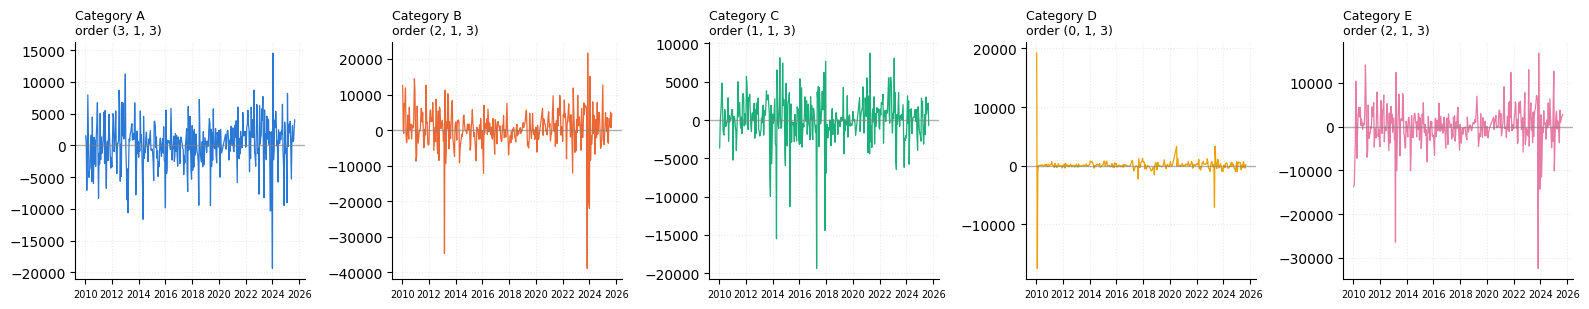

In [17]:
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(3.2 * len(CATEGORIES), 3.2))

for ax, category in zip(axes, CATEGORIES):
    fitted = fit_order(train[category]["premium"].to_numpy(), BEST_ORDER[category])
    residuals = fitted.resid[1:]               # first residual is the undifferenced start — skip
    ax.plot(train[category].index[1:], residuals, color=COLOR[category], linewidth=0.9)
    ax.axhline(0, color="gray", linewidth=1, alpha=0.6)
    ax.set_title(f"{category}\norder {BEST_ORDER[category]}", loc="left", fontsize=9)
    ax.tick_params(axis="x", labelsize=7)
    style_axis(ax)

plt.tight_layout()
plt.show()

## Step 5 — Honest backtest

The claim this project makes is a **backtested MAPE**, so this step has to be strict:

- **Expanding window, one round ahead.** For each of the 24 held-out rounds, fit on every
  round *before* it, forecast that one round, compare to the actual result. 24 real
  forecasts per category, each made without seeing its answer.
- **Refit every round** — exactly what the live app will do after each bidding exercise.
- **Beat the naive baseline or admit it.** The naive forecast — "next premium = last premium" —
  is embarrassingly strong for trending series. A model that can't beat it doesn't deserve
  its MAPE headline, so naive is in the table with everything else.
- **One spec, chosen a priori, not per-category off the holdout.** Prices have
  multiplicative errors → model `log(premium)`. The series trends → include a drift term.
  Picking whichever variant scores best per category *on the holdout* would quietly turn
  the holdout into training data, so the final model is the same spec for both categories.

| Contender | What it is |
|---|---|
| naive | next premium = last premium |
| arima | ARIMA(best order) on the raw premium |
| arima+quota | same + the upcoming round's quota (published in advance) |
| log+drift | ARIMA on log(premium) with drift — **the a-priori spec** |
| log+drift+quota | the a-priori spec + quota |

### 5.1 — The backtest loop

In [18]:
def backtest(category, use_quota=False, use_log=False, drift=False):
    """
    One-round-ahead forecasts over the holdout, expanding window, refit each round.
    Returns a DataFrame with actual and forecast per holdout round.
    """
    s = series[category]
    order = BEST_ORDER[category]
    trend = "c" if drift else None                 # with d=1, a constant term = drift
    n_train_start = len(s) - HOLDOUT

    rows = []
    for i in range(n_train_start, len(s)):
        past = s.iloc[:i]
        target_round = s.iloc[i]

        target = past["premium"].to_numpy()
        if use_log:
            target = np.log(target)

        if use_quota:
            exog = past["quota"].to_numpy()
            exog_next = [[target_round["quota"]]]
        else:
            exog = None
            exog_next = None

        model = SARIMAX(target, exog=exog, order=order, trend=trend,
                        enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False)
        forecast = fitted.forecast(1, exog=exog_next)[0]
        if use_log:
            forecast = np.exp(forecast)

        rows.append({"round_date": s.index[i],
                     "actual": target_round["premium"],
                     "forecast": forecast})

    return pd.DataFrame(rows).set_index("round_date")

def mape(actual, forecast):
    """
    Mean absolute percentage error, in percent.
    """
    return float((abs(forecast - actual) / actual).mean() * 100)

# The naive baseline needs no model — the forecast for round t is round t-1's premium
def backtest_naive(category):
    s = series[category]
    result = s.iloc[-HOLDOUT:][["premium"]].rename(columns={"premium": "actual"})
    result["forecast"] = s["premium"].shift(1).iloc[-HOLDOUT:]
    return result

# Example:
naive_a = backtest_naive("Category A")
print(f"naive Cat A MAPE: {mape(naive_a['actual'], naive_a['forecast']):.2f}%")
naive_a.head(3)

naive Cat A MAPE: 3.83%


,actual,forecast
round_date,,
2025-09-15,119003,107889.0
2025-10-01,128105,119003.0
2025-10-15,122000,128105.0


### 5.2 — Run all contenders

24 refits per contender per category (~a minute per contender).

In [19]:
CONTENDERS = {
    "arima": dict(),
    "arima+quota": dict(use_quota=True),
    "log+drift": dict(use_log=True, drift=True),
    "log+drift+quota": dict(use_log=True, drift=True, use_quota=True),
}

results = {}
for category in CATEGORIES:
    results[category] = {"naive": backtest_naive(category)}
    for name, spec in CONTENDERS.items():
        results[category][name] = backtest(category, **spec)
    print(f"{category} done")

Category A done


Category B done


Category C done


Category D done


Category E done


In [20]:
score_rows = []
for category in CATEGORIES:
    for name, result in results[category].items():
        score_rows.append({"category": category,
                           "model": name,
                           "MAPE %": round(mape(result["actual"], result["forecast"]), 2)})

scores = pd.DataFrame(score_rows).pivot(index="model", columns="category", values="MAPE %")
scores = scores.loc[["naive"] + list(CONTENDERS)]
print("Backtested MAPE, one round ahead, last 24 rounds:")
print(scores.to_string())

Backtested MAPE, one round ahead, last 24 rounds:
category         Category A  Category B  Category C  Category D  Category E
model                                                                      
naive                  3.83        4.64        1.94        4.52        2.69
arima                  3.90        4.34        1.90        4.90        2.79
arima+quota            3.84        4.43        1.90        4.83        2.79
log+drift              3.65        4.54        1.86        4.63        2.71
log+drift+quota        4.65        4.53        1.86        4.49        2.74


### 5.3 — Forecast vs. actual, round by round

The MAPE table says who wins; this shows *how*. Forecast (dashed) against actual (solid)
over the 24 held-out rounds.

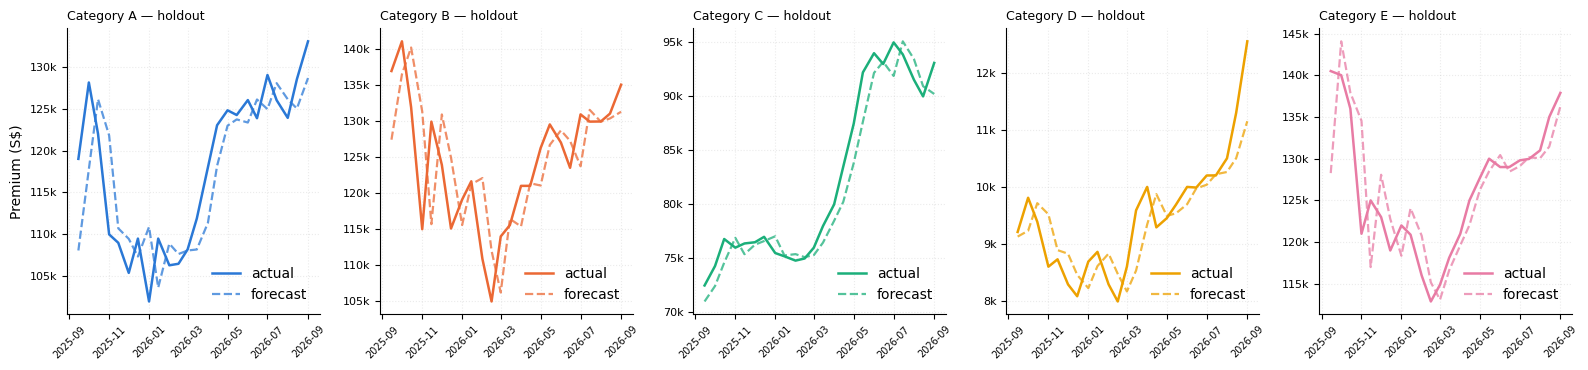

In [21]:
FINAL_MODEL = "log+drift"

fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(3.2 * len(CATEGORIES), 3.8))

for ax, category in zip(axes, CATEGORIES):
    best = results[category][FINAL_MODEL]
    ax.plot(best.index, best["actual"], color=COLOR[category], linewidth=1.8, label="actual")
    ax.plot(best.index, best["forecast"], color=COLOR[category], linewidth=1.6,
            linestyle="--", alpha=0.75, label="forecast")
    ax.set_title(f"{category} — holdout", loc="left", fontsize=9)
    ax.yaxis.set_major_formatter(lambda value, pos: f"{value/1000:.0f}k")
    ax.legend(frameon=False, loc="lower right")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)
    style_axis(ax)

axes[0].set_ylabel("Premium (S$)")
plt.tight_layout()
plt.show()

**The verdict:**

| | Cat A | Cat B | Cat C | Cat D | Cat E |
|---|---|---|---|---|---|
| naive baseline | 3.83% | 4.64% | 1.94% | 4.52% | 2.69% |
| **final model (log+drift)** | **3.65%** | **4.54%** | **1.86%** | 4.63% | 2.71% |

- **The final model beats naive in A, B and C** — modestly, which is the truthful result for
  auction price series that are close to a random walk. **In D and E naive wins narrowly**,
  and we report that rather than hide it: the same a-priori spec is kept for all five
  categories, because picking whichever variant scores best per category *on the holdout*
  would quietly turn the holdout into training data.
- **Quota didn't earn its place.** (`log+drift+quota` does edge out naive on Cat D — but
  selecting it *because* it won on the holdout is exactly the test-set selection this step
  refuses to do.) v1 ships without exogenous inputs, which also makes the live app simpler.
- The forecast lags sharp turns by about one round — inherent to this model class. The
  dashboard presents the forecast with its uncertainty interval, not as a point promise,
  and shows the naive comparison for every category.

## Step 6 — Save the artifacts for the Streamlit app

The app needs three things it should not recompute from scratch on every page load:
the final config (order per category), the **next-round forecast** with its interval
(fitted on ALL data — holdout included, since the backtest is done and reported),
and the backtest results that justify the headline MAPE.

### 6.1 — Fit the final models on everything and forecast the next round

In [22]:
import json

FINAL_ORDER = dict(BEST_ORDER)

def forecast_next_round(category):
    """
    Fit the final spec (log+drift, no exog) on the full series; forecast the next
    bidding round with a 95% interval, back-transformed to dollars.
    """
    s = series[category]
    model = SARIMAX(np.log(s["premium"].to_numpy()), order=FINAL_ORDER[category], trend="c",
                    enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)

    prediction = fitted.get_forecast(1)
    mean = float(np.exp(prediction.predicted_mean[0]))
    low, high = np.exp(prediction.conf_int(alpha=0.05)[0])
    return {"forecast": round(mean), "low": round(float(low)), "high": round(float(high))}

next_round = {}
for category in CATEGORIES:
    next_round[category] = forecast_next_round(category)
    latest = series[category]["premium"].iloc[-1]
    f = next_round[category]
    print(f"{category}: latest ${latest:,.0f} -> next round forecast ${f['forecast']:,} "
          f"(95% interval ${f['low']:,} – ${f['high']:,})")

Category A: latest $133,009 -> next round forecast $132,426 (95% interval $115,747 – $151,508)


Category B: latest $135,001 -> next round forecast $135,029 (95% interval $116,754 – $156,164)
Category C: latest $93,101 -> next round forecast $94,319 (95% interval $82,867 – $107,353)


Category D: latest $12,556 -> next round forecast $12,251 (95% interval $10,037 – $14,952)


Category E: latest $137,890 -> next round forecast $138,411 (95% interval $123,956 – $154,552)


### 6.2 — Write everything the app needs

- `dataset/coe_bidding_raw.csv` — already saved in Step 1 (the data fallback)
- `dataset/backtest_results.csv` — per-round actual vs. forecast for every contender
- `dataset/model_artifacts.json` — final orders, headline MAPEs, next-round forecast,
  and when it was generated

In [23]:
backtest_rows = []
for category in CATEGORIES:
    for name, result in results[category].items():
        for round_date, row in result.iterrows():
            backtest_rows.append({"category": category,
                                  "model": name,
                                  "round_date": round_date.date().isoformat(),
                                  "actual": row["actual"],
                                  "forecast": round(row["forecast"])})
backtest_df = pd.DataFrame(backtest_rows)
backtest_df.to_csv(ROOT / "dataset" / "backtest_results.csv", index=False)

artifacts = {
    "generated": pd.Timestamp.now().isoformat(timespec="seconds"),
    "final_model": "ARIMA on log(premium) with drift",
    "holdout_rounds": HOLDOUT,
    "categories": {},
}
for category in CATEGORIES:
    final = results[category][FINAL_MODEL]
    naive = results[category]["naive"]
    artifacts["categories"][category] = {
        "order": list(FINAL_ORDER[category]),
        "backtest_mape": round(mape(final["actual"], final["forecast"]), 2),
        "naive_mape": round(mape(naive["actual"], naive["forecast"]), 2),
        "latest_round": series[category].index[-1].date().isoformat(),
        "latest_premium": int(series[category]["premium"].iloc[-1]),
        "next_round": next_round[category],
    }

with open(ROOT / "dataset" / "model_artifacts.json", "w") as f:
    json.dump(artifacts, f, indent=2)

print("saved dataset/backtest_results.csv and dataset/model_artifacts.json\n")
print(json.dumps(artifacts, indent=2))

saved dataset/backtest_results.csv and dataset/model_artifacts.json

{
  "generated": "2026-09-18T17:36:39",
  "final_model": "ARIMA on log(premium) with drift",
  "holdout_rounds": 24,
  "categories": {
    "Category A": {
      "order": [
        3,
        1,
        3
      ],
      "backtest_mape": 3.65,
      "naive_mape": 3.83,
      "latest_round": "2026-09-01",
      "latest_premium": 133009,
      "next_round": {
        "forecast": 132426,
        "low": 115747,
        "high": 151508
      }
    },
    "Category B": {
      "order": [
        2,
        1,
        3
      ],
      "backtest_mape": 4.54,
      "naive_mape": 4.64,
      "latest_round": "2026-09-01",
      "latest_premium": 135001,
      "next_round": {
        "forecast": 135029,
        "low": 116754,
        "high": 156164
      }
    },
    "Category C": {
      "order": [
        1,
        1,
        3
      ],
      "backtest_mape": 1.86,
      "naive_mape": 1.94,
      "latest_round": "2026-09-01",
   